In [126]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import accuracy_score
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error



In [127]:
# Lire le CSV
df = pd.read_csv("data/df_num_cleaned.csv")
df=df.dropna()

In [128]:
pd.set_option("display.max_columns", None)
df.head()
#len(df)
#df.isna().sum()

,SDGi,Life Expectancy,HDI,Per Capita GDP,Population (millions),Cropland_Footprint_Production,Grazing_Footprint_Production,Forest_Footprint_Production,Fish_Footprint_Production,BuiltUp_Footprint_Production,Carbon_Footprint_Production,Total_Footprint_Production,Cropland_Footprint_Consumption,Grazing_Footprint_Consumption,Forest_Footprint_Consumption,Fish_Footprint_Consumption,BuiltUp_Footprint_Consumption,Carbon_Footprint_Consumption,Total_Footprint_Consumption,Cropland,Grazing land,Forest land,Fishing ground,BuiltUp_Biocapacity,Total_Biocapacity,Ecological (Deficit) or Reserve,Number of Earths required,Number of Countries required,Overshoot_Day_DOY,Income Group_LM,Income Group_UM,Income Group_HI,Quality Score_2B,Quality Score_2C,Quality Score_3A,Region_Asia-Pacific,Region_Central America/Caribbean,Region_EU,Region_Middle East/Central Asia,Region_North America,Region_Other Europe,Region_South America
1,71.0,78.4580,0.792,5046.032611,2.882740,0.362065,0.195718,0.163174,0.018087,0.042248,0.639822,1.421114,0.547458,0.195848,0.207561,0.040595,0.042248,0.852748,1.886458,0.362065,0.195718,0.310590,0.082072,0.042248,0.992693,-0.893765,1.191981,1.900343,305.0,0,1,0,0,0,1,0,0,0,0,0,1,0
2,70.9,76.6930,0.746,4759.830054,42.228398,0.249653,0.108329,0.079857,0.008417,0.037283,1.200642,1.684182,0.642917,0.150201,0.163528,0.013793,0.037283,1.333187,2.340909,0.249653,0.249356,0.025333,0.007541,0.037283,0.569166,-1.771742,1.479132,4.112872,245.0,0,1,0,0,0,1,0,0,0,0,0,0,0
5,72.8,76.5200,0.842,10076.395406,44.361102,2.207423,0.969692,0.250688,0.174034,0.092705,1.381537,5.076080,0.908614,0.717147,0.276678,0.083593,0.092705,1.233009,3.311746,2.207423,1.721421,0.609912,1.548194,0.092705,6.179656,2.867910,2.092567,0.535911,173.0,0,1,0,0,0,1,0,0,0,0,0,0,1
6,71.8,74.9450,0.771,4406.741763,2.951750,0.208557,0.156552,0.198053,0.000044,0.035763,0.652324,1.251293,0.482839,0.201365,0.267196,0.000756,0.035763,0.912473,1.900392,0.208557,0.263465,0.092649,0.015682,0.035763,0.616116,-1.284276,1.200786,3.084469,302.0,1,0,0,0,0,1,0,0,0,1,0,0,0
7,75.6,82.7488,0.943,57032.237052,24.898199,1.921158,2.413255,0.984093,0.041369,0.040870,5.445939,10.846684,0.765995,0.522429,0.947139,0.112822,0.040870,4.696784,7.086039,1.921158,4.613393,1.959529,2.936743,0.040870,11.471694,4.385655,4.477400,0.617698,80.0,0,0,1,0,0,1,1,0,0,0,0,0,0


In [129]:
features_tot = [
    'SDGi',
    'Life Expectancy',
    'HDI',
    'Per Capita GDP',
    'Population (millions)',

    'Cropland_Footprint_Production',
    'Grazing_Footprint_Production',
    'Forest_Footprint_Production',
    'Fish_Footprint_Production',
    'BuiltUp_Footprint_Production',
    'Carbon_Footprint_Production',

    'Cropland_Footprint_Consumption',
    'Grazing_Footprint_Consumption',
    'Forest_Footprint_Consumption',
    'Fish_Footprint_Consumption',
    'BuiltUp_Footprint_Consumption',
    'Carbon_Footprint_Consumption',

    'Cropland',
    'Grazing land',
    'Forest land',
    'Fishing ground',
    'BuiltUp_Biocapacity',

    'Ecological (Deficit) or Reserve',
    'Number of Earths required',
    'Number of Countries required',
    
    'Income Group_LM',
    'Income Group_UM',
    'Income Group_HI',

    'Quality Score_2B',
    'Quality Score_2C',
    'Quality Score_3A',

    'Region_Asia-Pacific',
    'Region_Central America/Caribbean',
    'Region_EU',
    'Region_Middle East/Central Asia',
    'Region_North America',
    'Region_Other Europe',
    'Region_South America'
]

In [130]:
'SDGi',
'Life Expectancy', 
'HDI', 
'Per Capita GDP', 
'Population (millions)', 
'Cropland_Footprint_Production', 
'BuiltUp_Footprint_Production', 
'Cropland_Footprint_Consumption', 
'Forest_Footprint_Consumption', 
'Fish_Footprint_Consumption', 
'Cropland', 
'Grazing land', 
'Ecological (Deficit) or Reserve', 
#'Number of Earths required', 
'Income Group_HI', 
'Region_Other Europe'

16

16

In [131]:
features=[
    'SDGi',
    'Life Expectancy',
    'HDI', 
    'Per Capita GDP', 
    'Population (millions)', 
    'Cropland_Footprint_Production', 
    'BuiltUp_Footprint_Production', 
    'Cropland_Footprint_Consumption', 
    'Forest_Footprint_Consumption', 
    'Fish_Footprint_Consumption', 
    'Cropland', 
    'Grazing land', 
    #'Ecological (Deficit) or Reserve', 
    #'Number of Earths required', 
    'Income Group_HI', 
    'Region_Other Europe'
]

In [132]:
X=df[features]

In [133]:
print(X)

     SDGi  Life Expectancy    HDI  Per Capita GDP  Population (millions)  \
1    71.0          78.4580  0.792     5046.032611               2.882740   
2    70.9          76.6930  0.746     4759.830054              42.228398   
5    72.8          76.5200  0.842    10076.395406              44.361102   
6    71.8          74.9450  0.771     4406.741763               2.951750   
7    75.6          82.7488  0.943    57032.237052              24.898199   
..    ...              ...    ...             ...                    ...   
173  70.2          77.8140  0.889    41325.060182               9.630960   
174  80.0          81.2561  0.928    42894.354268              67.141703   
175  76.0          78.6390  0.925    54723.995402             327.096000   
177  69.8          71.5730  0.717     2408.610055              32.476199   
180  72.8          75.3170  0.700     1967.638624              95.546000   

     Cropland_Footprint_Production  BuiltUp_Footprint_Production  \
1                  

In [134]:
Y = df["Overshoot_Day_DOY"]

In [135]:
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=123
)

In [136]:
print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

84
22
84
22


In [137]:
Y = df["Overshoot_Day_DOY"]

In [138]:
from sklearn.linear_model import LinearRegression

# Create model instance
model = LinearRegression()

# Fit the model
model.fit(X_train, y_train)

# Get model parameters
print(f"Slope (B1): {model.coef_[0]}")
print(f"Intercept (B0): {model.intercept_}")

# Predict values
y_pred = model.predict(X_test)
print("Predicted values:", y_pred)

print(len(y_pred))

Slope (B1): 6.802999487303024
Intercept (B0): 524.2661620537544
Predicted values: [162.09170428 109.24224288 190.98721537 209.17189673 112.51611086
 106.47038936 129.01694009 108.32431415 195.62973784 100.07115927
 179.26492933 -35.46643804 308.62215568 194.19346188 212.96173073
 227.0300631  101.62157603 113.4683229  258.21208188 247.67484376
 350.99616001  95.91493284]
22


In [139]:
# Évaluation
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 4923.849465774121


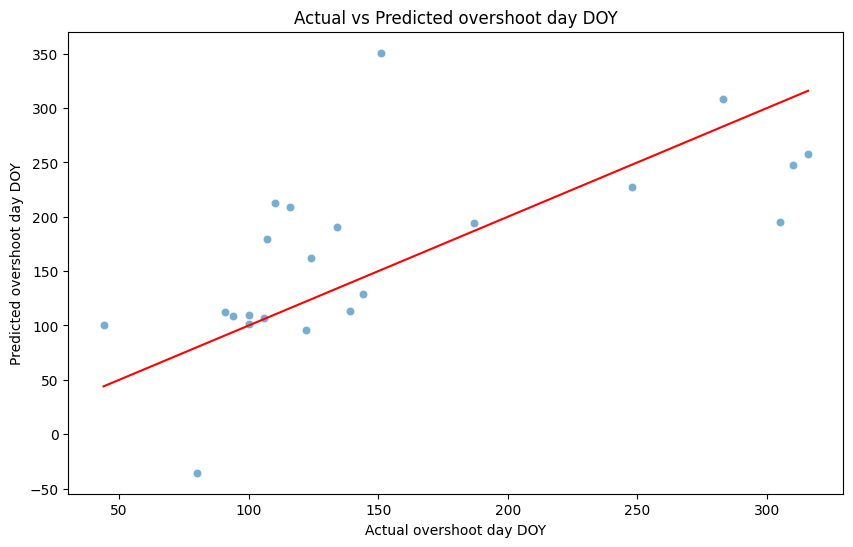

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the regression results
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
sns.lineplot(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()], color='red')
plt.title('Actual vs Predicted overshoot day DOY')
plt.xlabel('Actual overshoot day DOY')
plt.ylabel('Predicted overshoot day DOY')
plt.show()

On a des valeurs négatives, ce qui est pas possible.

On va prédire avec le log(y_train) et log(y_test).

In [141]:
from sklearn.linear_model import LinearRegression

# Create model instance
model = LinearRegression()

log_y_train=np.log(y_train)

# Fit the model
model.fit(X_train, log_y_train)

# Get model parameters
print(f"Slope (B1): {model.coef_[0]}")
print(f"Intercept (B0): {model.intercept_}")

# Predict values
log_y_pred = model.predict(X_test)

y_pred2 = np.exp(log_y_pred)
print("Predicted values:", y_pred2)

print(len(y_pred2))

Slope (B1): 0.04284278993342818
Intercept (B0): 6.622668126375151
Predicted values: [133.84087627 107.96517198 174.78179486 190.1035594  101.3584543
 104.20981054 110.29880842 103.59776282 191.23468571  80.09234468
 175.64704959  44.14760174 317.61565791 197.0740245  186.66156861
 223.41087507  99.86761798 104.91077219 230.48549834 237.82887694
 385.12701378  93.68934122]
22


In [142]:
# Évaluation
mse = mean_squared_error(y_test, y_pred2)
print("MSE:", mse)

MSE: 4817.180984621517


La MSE est quand même bien meilleure.

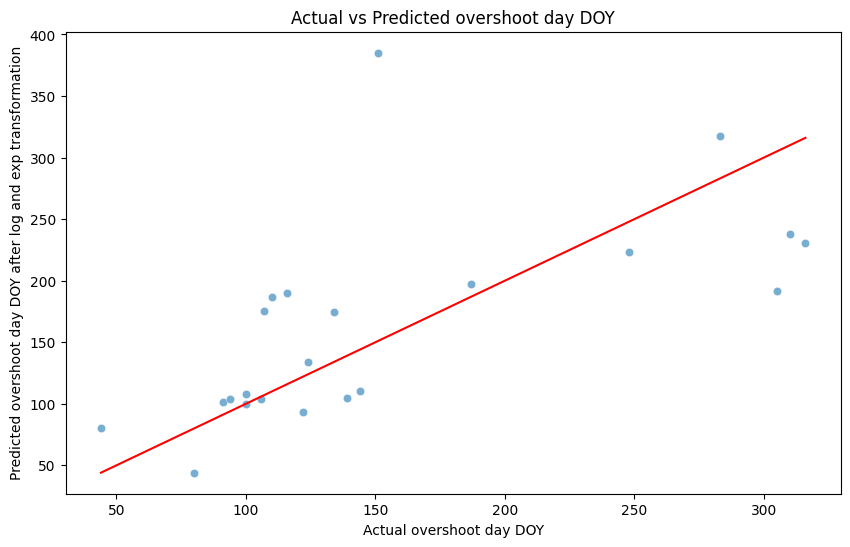

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the regression results
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred2, alpha=0.6)
sns.lineplot(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()], color='red')
plt.title('Actual vs Predicted overshoot day DOY')
plt.xlabel('Actual overshoot day DOY')
plt.ylabel('Predicted overshoot day DOY after log and exp transformation')
plt.show()

C'est mieux.

# Random Forest

Pour le random forest on peut mélanger des variables qualitatives et quantitatives mais il faut que ce soit des valeurs numériques.

In [144]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

In [145]:
df.head(2)

,SDGi,Life Expectancy,HDI,Per Capita GDP,Population (millions),Cropland_Footprint_Production,Grazing_Footprint_Production,Forest_Footprint_Production,Fish_Footprint_Production,BuiltUp_Footprint_Production,Carbon_Footprint_Production,Total_Footprint_Production,Cropland_Footprint_Consumption,Grazing_Footprint_Consumption,Forest_Footprint_Consumption,Fish_Footprint_Consumption,BuiltUp_Footprint_Consumption,Carbon_Footprint_Consumption,Total_Footprint_Consumption,Cropland,Grazing land,Forest land,Fishing ground,BuiltUp_Biocapacity,Total_Biocapacity,Ecological (Deficit) or Reserve,Number of Earths required,Number of Countries required,Overshoot_Day_DOY,Income Group_LM,Income Group_UM,Income Group_HI,Quality Score_2B,Quality Score_2C,Quality Score_3A,Region_Asia-Pacific,Region_Central America/Caribbean,Region_EU,Region_Middle East/Central Asia,Region_North America,Region_Other Europe,Region_South America
1,71.0,78.458,0.792,5046.032611,2.882740,0.362065,0.195718,0.163174,0.018087,0.042248,0.639822,1.421114,0.547458,0.195848,0.207561,0.040595,0.042248,0.852748,1.886458,0.362065,0.195718,0.310590,0.082072,0.042248,0.992693,-0.893765,1.191981,1.900343,305.0,0,1,0,0,0,1,0,0,0,0,0,1,0
2,70.9,76.693,0.746,4759.830054,42.228398,0.249653,0.108329,0.079857,0.008417,0.037283,1.200642,1.684182,0.642917,0.150201,0.163528,0.013793,0.037283,1.333187,2.340909,0.249653,0.249356,0.025333,0.007541,0.037283,0.569166,-1.771742,1.479132,4.112872,245.0,0,1,0,0,0,1,0,0,0,0,0,0,0


Test et train split (faut bien penser à déterminer les features, ici c'est fait plus haut)

In [146]:
X=df[features]

In [147]:
Y = df["Overshoot_Day_DOY"]

In [148]:
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=123
)

In [149]:
print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

84
22
84
22


In [150]:
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=123,
    n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=500, n_jobs=-1, random_state=123)

Hyper paramètres du random forest réalisé.

In [151]:
rf.get_params()
#on peut aussi aller sur le site de scikitlearn du randomforest pour voir les hyperparametre par défaut qui ont été utilisés vu qu'ici on a utilisé les paramètre par défaut.
#https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html 

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 500,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 123,
 'verbose': 0,
 'warm_start': False}

In [152]:
y_pred_rf = rf.predict(X_test)

In [153]:
# Évaluation
mse = mean_squared_error(y_test, y_pred_rf)
print("MSE:", mse)

MSE: 2944.6604934545458


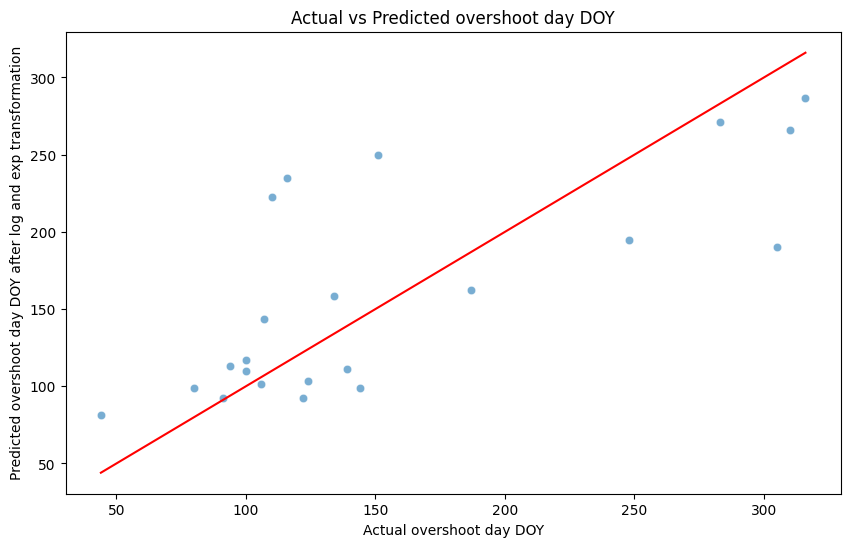

In [154]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the regression results
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
sns.lineplot(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()], color='red')
plt.title('Actual vs Predicted overshoot day DOY')
plt.xlabel('Actual overshoot day DOY')
plt.ylabel('Predicted overshoot day DOY after log and exp transformation')
plt.show()

#### Importance des variables par permutation

In [155]:
from sklearn.inspection import permutation_importance
import time

start_time = time.time()
result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=122, n_jobs=2
)
elapsed_time = time.time() - start_time
print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

forest_importances = pd.Series(result.importances_mean, index=features)

Elapsed time to compute the importances: 3.630 seconds


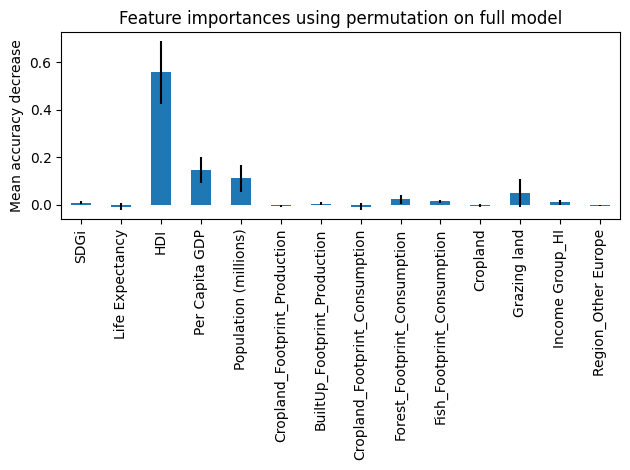

In [156]:
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()